In [1]:
# Cell 1: Install required libraries

!pip -q install -U transformers datasets evaluate accelerate

print("Required libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 19.1 MB/s eta 0:00:00
Required libraries installed successfully.


In [2]:
# Cell 2: Import required libraries

import os
import tarfile
import urllib.request
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# Cell 3: Set random seeds

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [4]:
# Cell 4: Download the IMDb dataset

DATA_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
ARCHIVE_PATH = "/content/aclImdb_v1.tar.gz"
DATA_DIR = "/content/aclImdb"

if not os.path.exists(DATA_DIR):
    print("Downloading IMDb dataset...")
    urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
    print("Download completed.")

    print("Extracting dataset...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall("/content")

    print("Extraction completed.")
else:
    print("IMDb dataset already exists.")

print("Dataset directory:", DATA_DIR)

Download completed.
Extracting dataset...


/tmp/ipykernel_724/1773657610.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content")


Extraction completed.
Dataset directory: /content/aclImdb


In [5]:
# Cell 5: Read IMDb reviews from text files

def read_reviews(folder):
    texts = []
    labels = []

    for label_name, label_value in [("neg", 0), ("pos", 1)]:
        label_folder = os.path.join(folder, label_name)

        for filename in os.listdir(label_folder):
            if filename.endswith(".txt"):
                filepath = os.path.join(label_folder, filename)

                with open(filepath, "r", encoding="utf-8") as f:
                    texts.append(f.read())

                labels.append(label_value)

    return texts, labels


train_texts, train_labels = read_reviews(
    os.path.join(DATA_DIR, "train")
)

test_texts, test_labels = read_reviews(
    os.path.join(DATA_DIR, "test")
)

print("Total training reviews:", len(train_texts))
print("Total testing reviews:", len(test_texts))

print("\nFirst review:")
print(train_texts[0][:1000])

print("\nFirst review label:")
print("Positive" if train_labels[0] == 1 else "Negative")

Total training reviews: 25000
Total testing reviews: 25000

First review:
I only gave this ridiculously titled comedy horror flick a 2 because several famous porn stars of the past appear in it. A group of tourists, supposedly on vacation in Ireland but actually in Canada, run afoul of a cannibalistic inbred mutant something or other, and the plot is more or less right out of THE HILL HAVE EYES ands WRONG TURN. Only problem is, unless I miscounted, there's only one mutant on display, and he isn't all that impressive. Sort of like the potbellied mummy in that homemade film from about five years ago. Some gory but silly deaths help, but the film is strictly amateur night and boring beyond belief. The ending is predictable and has been done to death. No pun intended.

First review label:
Negative


In [6]:
# Cell 6: Create Pandas DataFrames

train_df = pd.DataFrame({
    "text": train_texts,
    "label": train_labels
})

test_df = pd.DataFrame({
    "text": test_texts,
    "label": test_labels
})

print("Training DataFrame shape:", train_df.shape)
print("Testing DataFrame shape:", test_df.shape)

print("\nTraining label distribution:")
print(train_df["label"].value_counts().sort_index())

Training DataFrame shape: (25000, 2)
Testing DataFrame shape: (25000, 2)

Training label distribution:
label
0    12500
1    12500
Name: count, dtype: int64


In [7]:
# Cell 7: Create Hugging Face Dataset

dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df,
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df,
        preserve_index=False
    )
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
})


In [8]:
# Cell 8: Select a smaller subset for faster BERT training

# This makes the assignment practical to run in Google Colab.
# 5,000 training + 1,000 testing reviews are used.

train_dataset = dataset["train"].shuffle(
    seed=SEED
).select(range(5000))

test_dataset = dataset["test"].shuffle(
    seed=SEED
).select(range(1000))

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 5000
Testing samples: 1000


In [9]:
# Cell 9: Load pretrained BERT tokenizer

model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully.")
print("Model:", model_name)
print("Vocabulary size:", tokenizer.vocab_size)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully.
Model: bert-base-uncased
Vocabulary size: 30522


In [10]:
# Cell 10: Tokenize the reviews

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed.")
print(tokenized_train)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization completed.
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


In [11]:
# Cell 11: Load pretrained BERT for sequence classification

model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

# Label mappings
model.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

model.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

print("Pretrained BERT model loaded successfully.")
print("Number of labels:", model.config.num_labels)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pretrained BERT model loaded successfully.
Number of labels: 2


In [12]:
# Cell 12: Define evaluation metrics

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

print("Evaluation metrics configured.")

Evaluation metrics configured.


In [14]:
# Cell 13: Configure training parameters

training_args = TrainingArguments(
    output_dir="/content/bert_sentiment_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none",

    fp16=torch.cuda.is_available()
)

print("Training configuration created successfully.")

Training configuration created successfully.


In [15]:
# Cell 14: Create Hugging Face Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

print("Trainer initialized successfully.")

Trainer initialized successfully.


In [16]:
# Cell 15: Train the BERT model

print("Starting BERT fine-tuning...")
print("This may take several minutes depending on the Colab GPU.")

train_result = trainer.train()

print("\nTraining completed successfully!")

Starting BERT fine-tuning...
This may take several minutes depending on the Colab GPU.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.385016,0.333172,0.867000,0.866960
2,0.210304,0.467119,0.873000,0.872939


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


Training completed successfully!


In [17]:
# Cell 16: Evaluate the model

evaluation_results = trainer.evaluate()

print("BERT Evaluation Results")
print("=" * 40)

for key, value in evaluation_results.items():
    print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.210304,0.333843,2,0.866000,0.865954


BERT Evaluation Results
eval_loss: 0.33384305238723755
eval_accuracy: 0.866
eval_f1: 0.8659544354435443


In [18]:
# Cell 17: Generate predictions on the test dataset

prediction_output = trainer.predict(tokenized_test)

predicted_labels = np.argmax(
    prediction_output.predictions,
    axis=1
)

actual_labels = prediction_output.label_ids

print("Prediction completed.")
print("Number of predictions:", len(predicted_labels))

Prediction completed.
Number of predictions: 1000


In [19]:
# Cell 18: Classification report

print("Classification Report")
print("=" * 60)

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["Negative", "Positive"]
    )
)

Classification Report
              precision    recall  f1-score   support

    Negative       0.90      0.84      0.86       512
    Positive       0.84      0.90      0.87       488

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



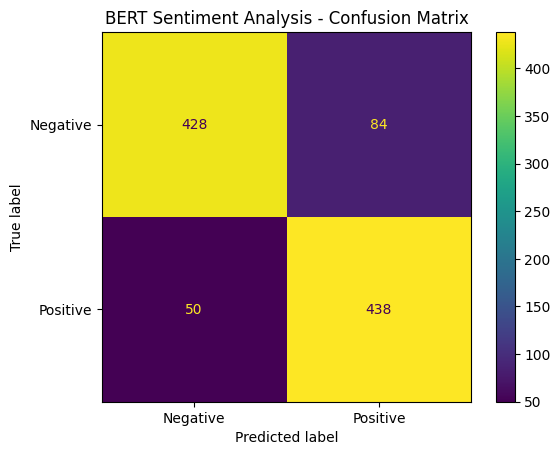

In [20]:
# Cell 19: Confusion matrix

cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("BERT Sentiment Analysis - Confusion Matrix")
plt.show()

In [21]:
# Cell 20: Function for custom sentiment prediction

def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    device = model.device

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )

    prediction = torch.argmax(
        probabilities,
        dim=-1
    ).item()

    labels = {
        0: "Negative",
        1: "Positive"
    }

    sentiment = labels[prediction]
    confidence = probabilities[0][prediction].item()

    return sentiment, confidence

In [22]:
# Cell 21: Test a positive review

review = "This movie was absolutely fantastic. The acting and story were excellent."

sentiment, confidence = predict_sentiment(review)

print("Review:")
print(review)

print("\nPredicted Sentiment:", sentiment)
print("Confidence:", round(confidence * 100, 2), "%")

Review:
This movie was absolutely fantastic. The acting and story were excellent.

Predicted Sentiment: Positive
Confidence: 98.84 %


In [23]:
# Cell 22: Test a negative review

review = "This movie was terrible and boring. I did not enjoy it at all."

sentiment, confidence = predict_sentiment(review)

print("Review:")
print(review)

print("\nPredicted Sentiment:", sentiment)
print("Confidence:", round(confidence * 100, 2), "%")

Review:
This movie was terrible and boring. I did not enjoy it at all.

Predicted Sentiment: Negative
Confidence: 98.74 %


In [24]:
# Cell 23: Test multiple custom reviews

reviews = [
    "I really enjoyed this movie. It was amazing!",
    "The movie was boring and poorly made.",
    "Excellent acting and a wonderful storyline.",
    "I regret watching this movie. It was terrible.",
    "The movie was okay but nothing special."
]

print("BERT SENTIMENT ANALYSIS")
print("=" * 70)

for review in reviews:
    sentiment, confidence = predict_sentiment(review)

    print("\nReview:", review)
    print("Sentiment:", sentiment)
    print("Confidence:", round(confidence * 100, 2), "%")

BERT SENTIMENT ANALYSIS

Review: I really enjoyed this movie. It was amazing!
Sentiment: Positive
Confidence: 98.69 %

Review: The movie was boring and poorly made.
Sentiment: Negative
Confidence: 98.62 %

Review: Excellent acting and a wonderful storyline.
Sentiment: Positive
Confidence: 98.71 %

Review: I regret watching this movie. It was terrible.
Sentiment: Negative
Confidence: 97.79 %

Review: The movie was okay but nothing special.
Sentiment: Positive
Confidence: 87.67 %


In [25]:
# Cell 24: Save the trained model

SAVE_PATH = "/content/bert_sentiment_model"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Model saved successfully.")
print("Location:", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.
Location: /content/bert_sentiment_model


In [26]:
# Cell 25: Load the saved model

loaded_tokenizer = BertTokenizer.from_pretrained(
    SAVE_PATH
)

loaded_model = BertForSequenceClassification.from_pretrained(
    SAVE_PATH
)

print("Saved BERT model loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved BERT model loaded successfully.


In [27]:
# Cell 26: Test the saved model

def predict_with_saved_model(text):

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    loaded_model.to(device)
    loaded_model.eval()

    inputs = loaded_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = loaded_model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )

    prediction = torch.argmax(
        probabilities,
        dim=-1
    ).item()

    labels = {
        0: "Negative",
        1: "Positive"
    }

    print("Text:", text)
    print("Predicted Sentiment:", labels[prediction])
    print(
        "Confidence:",
        round(
            probabilities[0][prediction].item() * 100,
            2
        ),
        "%"
    )


predict_with_saved_model(
    "The movie was wonderful and I loved every moment of it."
)

Text: The movie was wonderful and I loved every moment of it.
Predicted Sentiment: Positive
Confidence: 98.15 %
